# Factor Model Research Notebook

This notebook is the research memo for the factor pipeline in `equity_factor_lab/`.

**Strategy variants compared:**
- `EW__ALL`: equal-weight composite of all registered factors.
- `EW__DROP_STABLY_NEGATIVE`: equal-weight composite with a conservative negative-IC factor screen.
- `RIDGE__ALL`: walk-forward cross-sectional ridge on all factors, with settings fixed before the comparison below. Within each train window, ridge alpha is selected by train-window mean IC.

**Workflow:**
1. We fix the candidate strategy variants and window split before holdout.
2. We run data and QC diagnostics (hard cleaning, tradability mask, and coverage checks).
3. We evaluate each strategy variant on two expanding pre-holdout validation folds.
4. We pool the validation windows for a single recap table.
5. We choose one strategy variant for holdout beginning in 2020 based on pre-holdout evidence, with primary weight on net Sharpe and IC as a cross-check on signal quality; holdout then follows the same pre-specified walk-forward design, with one scheduled checkpoint (train-dependent variants may refresh at this checkpoint).

In [1]:
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import warnings
from IPython.display import display

from equity_factor_lab.config import SIMFIN_DATA_DIR
from equity_factor_lab.models.ridge import fit_walk_forward_ridge_scores
from equity_factor_lab.notebook_helpers.matrix import build_candidate_panels, build_selected_protocol_scores, evaluate_validation_matrix
from equity_factor_lab.notebook_helpers.triage import build_train_factor_report, select_drop_stably_negative_factors
from equity_factor_lab.notebook_helpers.qc import build_qc_display_tables
from equity_factor_lab.notebook_helpers.baseline import run_pipeline_core_quiet
from equity_factor_lab.notebook_helpers.utils import build_equity_curve, slice_panel
from equity_factor_lab.runner.pipeline import PipelineSettings

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 200)


In [2]:

# Suppress known third-party warnings from pandas/simfin internals.
warnings.filterwarnings("ignore", category=FutureWarning, module=r"simfin\\.load")
warnings.filterwarnings("ignore", category=RuntimeWarning, message=r".*divide by zero encountered in log10.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, message=r".*invalid value encountered in log10.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, message=r".*invalid value encountered in subtract.*")


## 1) Setup and Research Design

This section defines the fixed design for pre-holdout comparisons and the variant-specific scoring rules.

In [3]:
simfin_api_key = os.getenv("SIMFIN_API_KEY")
if not simfin_api_key:
    raise ValueError("SIMFIN_API_KEY is not set.")

data_start = pd.Timestamp("2007-01-01")
pre_holdout_start = pd.Timestamp("2008-01-01")
pre_holdout_end = pd.Timestamp("2019-12-31")

common_settings = PipelineSettings(
    start_date=data_start.strftime("%Y-%m-%d"),
    neutralization_mode="sector",
    simfin_api_key=simfin_api_key,
    simfin_data_dir=str(SIMFIN_DATA_DIR),
    universe_max_tickers=1500,
)

fold_1 = {
    "fold": "FOLD_1",
    "train_end": pd.Timestamp("2013-12-31"),
    "val_start": pd.Timestamp("2014-01-01"),
    "val_end": pd.Timestamp("2016-12-31"),
}
fold_2 = {
    "fold": "FOLD_2",
    "train_end": pd.Timestamp("2016-12-31"),
    "val_start": pd.Timestamp("2017-01-01"),
    "val_end": pd.Timestamp("2019-12-31"),
}

rebalance_freq = "W-FRI"
turnover_cost_rate = 0.0010
borrow_cost_rate_annual = 0.03
ridge_window_type = "rolling"
ridge_window_size = 156
ridge_refit_every_n_rebalances = 12
ridge_alpha_grid = (0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0)

### Shared Design Controls

- **Data:** SimFin US daily data. We load history from `2007-01-01` so the first design date in `2008` starts with fully formed long-lookback factors.
- **Base return alignment:** factor scores at date `t` are evaluated against forward returns after `t`. For weekly evaluation (`W-FRI`), IC and backtest returns are computed on rebalance intervals rather than from daily returns.
- **Universe:** dynamic tradable subset with point-in-time liquidity and price filters, a point-in-time data-quality screen, score availability, and the pre-specified universe cap.
- **Factors:** all registered price and fundamental factors, processed through the same winsorization, neutralization, and standardization pipeline.
- **Neutralization:** fixed to `sector` throughout. This removes broad within-sector level effects while keeping the exercise focused on stock selection rather than sector timing.
- **Rebalance frequency:** fixed to `W-FRI`. Weekly gives materially more IC observations than monthly while avoiding the turnover intensity of daily trading.
- **Cost assumptions:** turnover cost `10 bps` per unit traded and borrow cost `3%` annualized on the short book. For weekly rebalancing in a liquid US equity universe, these are meant to be simple but reasonably cautious assumptions.

### Variant-Specific Rules

**EW__DROP_STABLY_NEGATIVE**
- **Screening rule:** removes only factors with negative full-train IC and negative IC in both train halves.

**RIDGE__ALL**
- **Window type:** `rolling`
- **Window size:** `156` weekly rebalance observations (about 3 years)
- **Refit cadence:** every `12` weekly rebalances
- **Alpha tuning:** chosen from `(0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0)` by train-window mean IC.
- **Setting choice note:** the window type, size and refit cadence were chosen based on preliminary pre-holdout trial runs and were kept fixed in the main comparison.


### Window Split

- Warm-up / load start: `2007-01-01`
- Pre-holdout design window: `2008-01-01` to `2019-12-31`
- Fold 1 train: `2008-01-01` to `2013-12-31`
- Fold 1 validation: `2014-01-01` to `2016-12-31`
- Fold 2 train: `2008-01-01` to `2016-12-31`
- Fold 2 validation: `2017-01-01` to `2019-12-31`
- Holdout start: `2020-01-01`
- First scheduled holdout checkpoint date: `2023-01-01`

All strategy-variant selection is done using the two pre-holdout validation folds. Holdout is reserved for the final readout.


In [4]:
pre_holdout_result = run_pipeline_core_quiet(
    settings=replace(
        common_settings,
        end_date=pre_holdout_end.strftime("%Y-%m-%d"),
        rebalance_freq=rebalance_freq,
        turnover_cost_rate=turnover_cost_rate,
        borrow_cost_rate_annual=borrow_cost_rate_annual,
    )
)

prices = pre_holdout_result.prices
future_returns = pre_holdout_result.future_returns.where(np.isfinite(pre_holdout_result.future_returns))
factor_panels = {
    name: panel
    for name, panel in pre_holdout_result.factor_scores.items()
    if name not in {"composite", "ridge"}
}


## 2) Data Snapshot and QC

This section documents the input data and deterministic cleaning rules used before factor evaluation and backtesting.

### Cleaning Policy

The cleaning is automated and follows a few rules:

- **Hard drops before factor construction:** remove non-finite or non-positive prices, returns below `-100%`, and returns at or above `+1000%`.
- **Large positive event review:** returns from `+300%` to below `+1000%` are flagged for diagnostic review using spike-reversal, persistent-shift, and stale-jump rules (these flags are for inspection only and do not trigger additional dropping).
- **Tradability layer:** after cleaning, the strategy applies eligibility rules: price floor, point-in-time liquidity screen, point-in-time data-quality screen (rolling coverage and hard-event checks), score availability, and top-`N` universe cap.

### QC Tables

`raw_daily` is the source daily price panel before hard cleaning and the strategy eligibility filters. `tradable_daily` is the subset that remains after hard cleaning and the eligibility filters are applied.

`removed_price_observations`, `removed_observation_frac`, and `assets_with_removed_observations` refer to hard-cleaning impact only.

### Price Panel Snapshot

In [5]:
qc_tables = build_qc_display_tables(
    qc_raw_daily=pre_holdout_result.qc_raw_daily,
    qc_tradable_daily=pre_holdout_result.qc_tradable_daily,
    qc_cleaning_diff=pre_holdout_result.qc_cleaning_diff,
)

display(qc_tables["overview"].style.hide(axis="index"))
display(qc_tables["tails"].style.hide(axis="index"))


panel,observed_prices
raw_daily,10931016
tradable_daily,3904922


panel,daily_ret_min,daily_ret_p01,daily_ret_p99,daily_ret_p999,daily_ret_max
raw_daily,-0.999586,-0.100000,0.113821,0.402936,194477.260870
tradable_daily,-0.946429,-0.079596,0.086142,0.215645,7.523810


Observed prices fall from about `10.9` million in `raw_daily` to about `3.9` million in `tradable_daily`. 

Return tails compress materially once the tradable subset is applied. The raw panel contains clearly implausible extremes, whereas the tradable panel retains large but much more plausible ones. This is the intended outcome; we remove bad data without sanitizing away stress events.

### Hard-Cleaning Impact

In [6]:
display(qc_tables["cleaning_impact"].style.hide(axis="index"))

removed_price_observations,removed_observation_frac,assets_with_removed_observations
129,0.000012,82


Hard cleaning has a negligible effect on price counts. Only `129` price observations are removed out of more than `10.9` million, which is consistent with a targeted repair step rather than a material sample reshaping. The large raw to tradable reduction seen above is therefore driven mainly by the eligibility filters rather than the hard cleaning itself.

### Suspect Event Diagnostics

In [7]:
display(qc_tables["suspect_event_qa"].style.hide(axis="index"))

metric,value
n_large_positive_candidates,288
n_suspect_events,203
n_spike_reversal,12
n_persistent_shift,165
n_stale_jump,82
n_assets_with_any_suspect_event,115


Large positive jumps are present but still sparse relative to the full panel: `288` candidates are reviewed, `203` are flagged by at least one suspect rule (rule categories can overlap). Persistent-shift is the most frequently triggered suspect rule, which supports keeping this layer as QA rather than turning it into an automatic exclusion rule.


### Score and Factor Coverage Snapshot

The table below summarizes score and factor coverage after the tradable mask.

- `non_null_frac`: share of non-null values over tradable cells.
- `date_coverage_p50`: median of per-date stock coverage. 
- `stock_coverage_p50`: median of per-stock date coverage.

In [8]:
display(pre_holdout_result.factor_qc_stats.style.hide(axis="index"))


factor,non_null_frac,date_coverage_p50,stock_coverage_p50,value_p01,value_p99
composite,1.000000,1.000000,1.000000,-1.149572,0.833775
growth,0.948757,0.972000,0.970842,-2.892124,3.839950
invest,0.904716,0.924667,0.970885,-4.764713,1.505318
low_vol,1.000000,1.000000,1.000000,-2.299742,1.437822
momentum,1.000000,1.000000,1.000000,-1.830538,3.864826
quality,0.926657,0.936000,1.000000,-2.641078,2.131137
reversal,1.000000,1.000000,1.000000,-2.988784,2.333144
value,0.994734,0.995333,1.000000,-2.216897,2.802062


Factor coverage is generally strong. Price-based factors are effectively full-coverage, while the fundamental factors are somewhat sparser but still broad enough for the comparison to be meaningful. `invest` is the sparsest input at about `90%` non-null, with `growth` and `quality` still around `93-95%`, so this table does not argue for an additional ad hoc coverage screen.


## 3) Expanding Validation Folds

This section applies the same fixed research design across two pre-holdout expanding folds. In each fold, the first table reports train-window factor diagnostics and the second reports the corresponding out-of-sample validation comparison.

The goal is to check whether the relative ranking of the three candidate strategy variants is stable before pooling the validation results.


### Fold 1

Train: January 1, 2008 to December 31, 2013  
Validation: January 1, 2014 to December 31, 2016

This is the first out-of-sample check. The training window spans the 2008-2009 crisis and early recovery.


In [9]:
train_factor_report = build_train_factor_report(
    factor_panels=factor_panels,
    future_returns=future_returns,
    prices=prices,
    train_start=pre_holdout_start,
    train_end=fold_1["train_end"],
    rebalance_freq=rebalance_freq,
)
display(train_factor_report.style.hide(axis="index"))

all_factors = train_factor_report["factor"].tolist()

screened_factors = select_drop_stably_negative_factors(train_factor_report)
protocols = build_candidate_panels(
    factor_panels=factor_panels,
    candidate_factors={
        "EW__ALL": all_factors,
        "EW__DROP_STABLY_NEGATIVE": screened_factors,
    },
)
alpha_map = {"EW__ALL": np.nan, "EW__DROP_STABLY_NEGATIVE": np.nan}
for ridge_name, factor_list in {
    "RIDGE__ALL": all_factors,
}.items():
    ridge_fit = fit_walk_forward_ridge_scores(
        factor_scores={name: factor_panels[name] for name in factor_list},
        future_returns=future_returns,
        prices=prices,
        rebalance_freq=rebalance_freq,
        tuning_cutoff_date=fold_1["val_start"].strftime("%Y-%m-%d"),
        alpha_grid=ridge_alpha_grid,
        window_type=ridge_window_type,
        window_size=ridge_window_size,
        refit_every_n_rebalances=ridge_refit_every_n_rebalances,
    )
    protocols[ridge_name] = ridge_fit.scores
    alpha_map[ridge_name] = float(ridge_fit.best_alpha)

matrix = evaluate_validation_matrix(
    constructs=protocols,
    future_returns=future_returns,
    prices=prices,
    start=fold_1["val_start"],
    end=fold_1["val_end"],
    rebalance_freq=rebalance_freq,
    turnover_cost_rate=turnover_cost_rate,
    borrow_cost_rate_annual=borrow_cost_rate_annual,
)
matrix.insert(
    1,
    "ridge_alpha",
    matrix["construct"].map(alpha_map).map(lambda x: "" if pd.isna(x) else f"{x:g}"),
)
display(matrix.style.hide(axis="index"))

fold_1_protocols = {
    name: slice_panel(panel, start_date=fold_1["val_start"], end_date=fold_1["val_end"])
    for name, panel in protocols.items()
}
fold_1_matrix = matrix


factor,train_ic_mean_spearman,train_ic_t_nw_spearman,train_ic_n_obs,train_ic_mean_first_half,train_ic_mean_second_half
low_vol,0.024185,4.206270,313,0.019454,0.028946
reversal,0.022216,4.154063,313,0.030309,0.014071
quality,0.016290,3.746884,313,0.015357,0.017228
momentum,0.008463,1.101757,313,-0.007243,0.024270
value,0.003443,0.984782,313,0.006655,0.000211
growth,0.000413,0.137002,300,-0.003493,0.004017
invest,-0.004572,-1.305380,301,-0.000823,-0.008056


construct,ridge_alpha,mean_ic,t_ic_newey_west,sharpe_gross,sharpe_net,max_drawdown_net,turnover_mean,turnover_cost_drag_ann,borrow_cost_drag_ann
EW__ALL,,0.014059,2.069432,0.666360,0.098877,-0.265213,0.922478,0.048276,0.029960
RIDGE__ALL,10000,-0.001754,-0.186398,0.498579,-0.096460,-0.393763,1.238839,0.064833,0.029960
EW__DROP_STABLY_NEGATIVE,,0.012611,1.794236,0.366469,-0.163130,-0.302133,0.957353,0.050101,0.029960


In the Fold 1 train diagnostics, `low_vol`, `reversal`, and `quality` are the strongest and most stable signals. `invest` is the only factor that is negative on the full train sample and on both train halves, so it is the only factor removed by `EW__DROP_STABLY_NEGATIVE`.

The validation table clearly favors `EW__ALL`: it has the strongest validation IC and the only positive net Sharpe of the three strategy variants. `EW__DROP_STABLY_NEGATIVE` is the weakest on net Sharpe in this fold, which suggests the screen did not help here and may have reduced diversification.

`RIDGE__ALL` selects the highest alpha in the grid (`10000`) and remains weak: it has the lowest IC of the three and a negative net Sharpe.


### Fold 2

Train: January 1, 2008 to December 31, 2016  
Validation: January 1, 2017 to December 31, 2019

This repeats the same comparison on a new validation window with a longer expanding training sample. The 2017-2019 validation window tests whether the Fold 1 ranking persists.


In [10]:
train_factor_report = build_train_factor_report(
    factor_panels=factor_panels,
    future_returns=future_returns,
    prices=prices,
    train_start=pre_holdout_start,
    train_end=fold_2["train_end"],
    rebalance_freq=rebalance_freq,
)
display(train_factor_report.style.hide(axis="index"))

all_factors = train_factor_report["factor"].tolist()

screened_factors = select_drop_stably_negative_factors(train_factor_report)
protocols = build_candidate_panels(
    factor_panels=factor_panels,
    candidate_factors={
        "EW__ALL": all_factors,
        "EW__DROP_STABLY_NEGATIVE": screened_factors,
    },
)
alpha_map = {"EW__ALL": np.nan, "EW__DROP_STABLY_NEGATIVE": np.nan}
for ridge_name, factor_list in {
    "RIDGE__ALL": all_factors,
}.items():
    ridge_fit = fit_walk_forward_ridge_scores(
        factor_scores={name: factor_panels[name] for name in factor_list},
        future_returns=future_returns,
        prices=prices,
        rebalance_freq=rebalance_freq,
        tuning_cutoff_date=fold_2["val_start"].strftime("%Y-%m-%d"),
        alpha_grid=ridge_alpha_grid,
        window_type=ridge_window_type,
        window_size=ridge_window_size,
        refit_every_n_rebalances=ridge_refit_every_n_rebalances,
    )
    protocols[ridge_name] = ridge_fit.scores
    alpha_map[ridge_name] = float(ridge_fit.best_alpha)

matrix = evaluate_validation_matrix(
    constructs=protocols,
    future_returns=future_returns,
    prices=prices,
    start=fold_2["val_start"],
    end=fold_2["val_end"],
    rebalance_freq=rebalance_freq,
    turnover_cost_rate=turnover_cost_rate,
    borrow_cost_rate_annual=borrow_cost_rate_annual,
)
matrix.insert(
    1,
    "ridge_alpha",
    matrix["construct"].map(alpha_map).map(lambda x: "" if pd.isna(x) else f"{x:g}"),
)
display(matrix.style.hide(axis="index"))

fold_2_protocols = {
    name: slice_panel(panel, start_date=fold_2["val_start"], end_date=fold_2["val_end"])
    for name, panel in protocols.items()
}
fold_2_matrix = matrix


factor,train_ic_mean_spearman,train_ic_t_nw_spearman,train_ic_n_obs,train_ic_mean_first_half,train_ic_mean_second_half
low_vol,0.024757,5.059206,469,0.024428,0.025169
reversal,0.018730,4.286234,469,0.026787,0.008620
quality,0.013410,3.838755,469,0.017466,0.008321
momentum,0.010752,1.821377,469,0.006052,0.016650
growth,0.002403,1.008960,456,-0.002374,0.008098
value,0.002328,0.758416,469,0.002906,0.001603
invest,-0.004220,-1.647009,457,-0.002955,-0.005735


construct,ridge_alpha,mean_ic,t_ic_newey_west,sharpe_gross,sharpe_net,max_drawdown_net,turnover_mean,turnover_cost_drag_ann,borrow_cost_drag_ann
EW__DROP_STABLY_NEGATIVE,,0.015543,2.638937,0.897969,0.185264,-0.133844,0.976830,0.051065,0.029880
EW__ALL,,0.012130,2.161546,0.695152,-0.103090,-0.163019,0.931218,0.048681,0.029880
RIDGE__ALL,10000,0.008317,1.336917,0.488435,-0.391169,-0.179253,1.198062,0.062631,0.029840


The Fold 2 train diagnostics look broadly similar to Fold 1: `low_vol`, `reversal`, and `quality` remain the strongest inputs, while `invest` remains the only clearly stably negative factor.

The validation table flips the ranking between the two equal-weight strategy variants, which points to some regime dependence. Here `EW__DROP_STABLY_NEGATIVE` is best on both mean IC and net Sharpe.

`RIDGE__ALL` again selects `alpha = 10000`. It is weakest on net Sharpe in this fold, so the added complexity once again does not translate into stronger performance.



## 4) Pooled Validation Recap

The pooled recap concatenates the two validation windows into one pre-holdout summary.


In [11]:
pooled_protocols = {
    name: pd.concat([fold_1_protocols[name], fold_2_protocols[name]]).sort_index()
    for name in fold_1_protocols
}

pooled_matrix = evaluate_validation_matrix(
    constructs=pooled_protocols,
    future_returns=future_returns,
    prices=prices,
    start=fold_1["val_start"],
    end=fold_2["val_end"],
    rebalance_freq=rebalance_freq,
    turnover_cost_rate=turnover_cost_rate,
    borrow_cost_rate_annual=borrow_cost_rate_annual,
)

display(pooled_matrix.style.hide(axis="index"))


construct,mean_ic,t_ic_newey_west,sharpe_gross,sharpe_net,max_drawdown_net,turnover_mean,turnover_cost_drag_ann,borrow_cost_drag_ann
EW__ALL,0.012669,2.888314,0.660521,0.007122,-0.265213,0.923492,0.048303,0.029980
EW__DROP_STABLY_NEGATIVE,0.013688,3.003498,0.588202,-0.012275,-0.302133,0.963945,0.050419,0.029980
RIDGE__ALL,0.003651,0.648576,0.508534,-0.183780,-0.393763,1.216381,0.063623,0.029960


The pooled table shows `RIDGE__ALL` is clearly weaker: it has the lowest IC, the lowest gross and net Sharpe, and the deepest drawdown. Across both folds it also selected the strongest shrinkage (`alpha = 10000`), which indicates limited benefit from adaptive linear reweighting in this setup.

Between the two equal-weight strategy variants, the result is close: `EW__DROP_STABLY_NEGATIVE` is slightly better on IC, while `EW__ALL` is slightly better on net Sharpe and drawdown. Pre-holdout evidence is weak but because we place primary weight on net Sharpe and use IC as a cross-check, `EW__ALL` is carried into holdout.

## 5) Holdout (2020+)

We carry `EW__ALL` into holdout and apply it from `2020-01-01` onward.

Holdout follows the same pre-specified walk-forward protocol and reports the planned `2023-01-01` checkpoint as a separate block (`2023+`). For `EW__ALL` specifically, this does not involve a new selection step, but it provides a simple stability split.

In [ ]:
holdout_block_2_start = pd.Timestamp("2023-01-01")
holdout_block_1_end = holdout_block_2_start - pd.Timedelta(days=1)

selected_selection_rule = "all"
selected_combine_method = "ew"
selected_protocol_label = (
    f"{selected_combine_method.upper()}__{selected_selection_rule.upper()}"
)

full_settings = replace(
    common_settings,
    end_date=None,
    rebalance_freq=rebalance_freq,
    turnover_cost_rate=turnover_cost_rate,
    borrow_cost_rate_annual=borrow_cost_rate_annual,
)
full_result = run_pipeline_core_quiet(settings=full_settings)
full_prices = full_result.prices
full_future_returns = full_result.future_returns.where(np.isfinite(full_result.future_returns))
full_factor_panels = {
    name: panel
    for name, panel in full_result.factor_scores.items()
    if name not in {"composite", "ridge"}
}

full_end = pd.Timestamp(full_prices.index.max())
holdout_blocks = [
    {
        "block": "2020-2022",
        "train_end": pre_holdout_end,
        "start": pd.Timestamp("2020-01-01"),
        "end": holdout_block_1_end,
    }
]

holdout_blocks.append(
    {
        "block": "2023+",
        "train_end": holdout_block_1_end,
        "start": holdout_block_2_start,
        "end": full_end,
    }
)

holdout_scores = {
    block["block"]: build_selected_protocol_scores(
        combine_method=selected_combine_method,
        selection_rule=selected_selection_rule,
        factor_panels=full_factor_panels,
        future_returns=full_future_returns,
        prices=full_prices,
        train_start=pre_holdout_start,
        train_end=block["train_end"],
        rebalance_freq=rebalance_freq,
        score_start=block["start"],
        score_end=block["end"],
        alpha_grid=ridge_alpha_grid,
        refit_every_n_rebalances=ridge_refit_every_n_rebalances,
        ridge_window_type=ridge_window_type,
        ridge_window_size=ridge_window_size,
    )
    for block in holdout_blocks
}
combined_holdout_scores = pd.concat(holdout_scores.values(), axis=0).sort_index()
holdout_constructs = dict(holdout_scores)
holdout_constructs["2020+"] = combined_holdout_scores
holdout_start_map = {
    block["block"]: block["start"].strftime("%Y-%m-%d")
    for block in holdout_blocks
}
holdout_end_map = {
    block["block"]: block["end"].strftime("%Y-%m-%d")
    for block in holdout_blocks
}
holdout_start_map["2020+"] = holdout_blocks[0]["start"].strftime("%Y-%m-%d")
holdout_end_map["2020+"] = full_end.strftime("%Y-%m-%d")


### Holdout Summary by Block


In [13]:
holdout_summary_view = evaluate_validation_matrix(
    constructs=holdout_constructs,
    future_returns=full_future_returns,
    prices=full_prices,
    start=holdout_blocks[0]["start"],
    end=full_end,
    rebalance_freq=rebalance_freq,
    turnover_cost_rate=turnover_cost_rate,
    borrow_cost_rate_annual=borrow_cost_rate_annual,
).rename(columns={"construct": "block"})

holdout_order = {label: i for i, label in enumerate([block["block"] for block in holdout_blocks] + ["2020+"])}
holdout_summary_view["start"] = holdout_summary_view["block"].map(holdout_start_map)
holdout_summary_view["end"] = holdout_summary_view["block"].map(holdout_end_map)
holdout_summary_view["_order"] = holdout_summary_view["block"].map(holdout_order)
holdout_summary_view = holdout_summary_view.sort_values("_order").drop(columns="_order").reset_index(drop=True)
display(holdout_summary_view.style.hide(axis="index"))


block,mean_ic,t_ic_newey_west,sharpe_gross,sharpe_net,max_drawdown_net,turnover_mean,turnover_cost_drag_ann,borrow_cost_drag_ann,start,end
2020-2022,0.019826,2.122234,0.615688,0.281631,-0.410335,0.977221,0.051141,0.029960,2020-01-01,2022-12-31
2023+,0.013577,1.780421,0.640287,0.192418,-0.246173,0.927782,0.048770,0.029886,2023-01-01,2026-03-02
2020+,0.016708,2.749276,0.618678,0.241261,-0.410335,0.948316,0.049742,0.029981,2020-01-01,2026-03-02


Holdout is positive in both blocks. Relative to `2020-2022`, the `2023+` block has lower IC and lower net Sharpe, with similar gross Sharpe and shallower drawdown. Over the full `2020+` holdout, performance is clearly positive after costs, but the edge is still modest.

The strategy remains viable in holdout, but the drawdown profile shows a lack of robustness (max drawdown: -0.41).

### Holdout Equity Curve


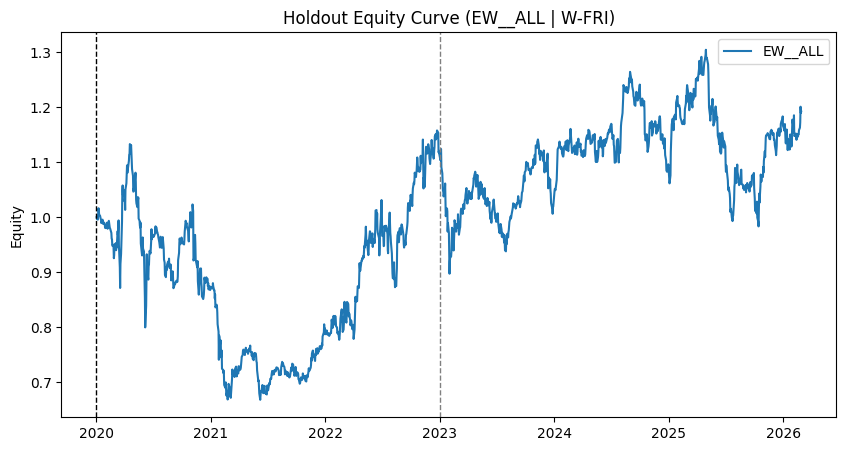

In [14]:
holdout_equity_curve = build_equity_curve(
    scores=combined_holdout_scores,
    future_returns=full_future_returns,
    rebalance_freq=rebalance_freq,
    turnover_cost_rate=turnover_cost_rate,
    borrow_cost_rate_annual=borrow_cost_rate_annual,
)
holdout_equity_curve = holdout_equity_curve.loc[holdout_equity_curve.index >= holdout_blocks[0]["start"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(holdout_equity_curve.index, holdout_equity_curve.values, label=selected_protocol_label)
ax.axvline(holdout_blocks[0]["start"], linestyle="--", color="black", linewidth=1.0)

ax.axvline(holdout_block_2_start, linestyle="--", color="gray", linewidth=1.0)
ax.set_title(f"Holdout Equity Curve ({selected_protocol_label} | {rebalance_freq})")
ax.set_ylabel("Equity")
ax.legend()
plt.show()


The equity curve is consistent with the summary table, including the meaningful full-period drawdown.